In [159]:
import pandas 
import numpy as np
import matplotlib
import matplotlib.pylab as plt

#plt.rcParams['legend.title_fontsize'] = 'small'
#plt.rcParams["legend.title_fontsize"] = "small"
font_size = 8
matplotlib.rc("xtick", labelsize=font_size)
matplotlib.rc("ytick", labelsize=font_size)
matplotlib.rc("axes", labelsize=font_size)
matplotlib.rc("axes", titlesize=font_size)
matplotlib.rc("legend", fontsize=font_size)

In [160]:
chrom = 1
scale = int(1e6)

/tmp/ipykernel_5280/4134023673.py:11: RuntimeWarning: Mean of empty slice
  mut_map[i] = np.nanmean(site_mut_map[start:end])
/tmp/ipykernel_5280/4134023673.py:27: RuntimeWarning: Mean of empty slice
  rec_map[i] = np.nanmean(site_rec_map[start:end])
/tmp/ipykernel_5280/4134023673.py:11: RuntimeWarning: Mean of empty slice
  mut_map[i] = np.nanmean(site_mut_map[start:end])
/tmp/ipykernel_5280/4134023673.py:27: RuntimeWarning: Mean of empty slice
  rec_map[i] = np.nanmean(site_rec_map[start:end])
/tmp/ipykernel_5280/4134023673.py:11: RuntimeWarning: Mean of empty slice
  mut_map[i] = np.nanmean(site_mut_map[start:end])
/tmp/ipykernel_5280/4134023673.py:27: RuntimeWarning: Mean of empty slice
  rec_map[i] = np.nanmean(site_rec_map[start:end])
/tmp/ipykernel_5280/4134023673.py:27: RuntimeWarning: Mean of empty slice
  rec_map[i] = np.nanmean(site_rec_map[start:end])
/tmp/ipykernel_5280/4134023673.py:27: RuntimeWarning: Mean of empty slice
  rec_map[i] = np.nanmean(site_rec_map[start:end])


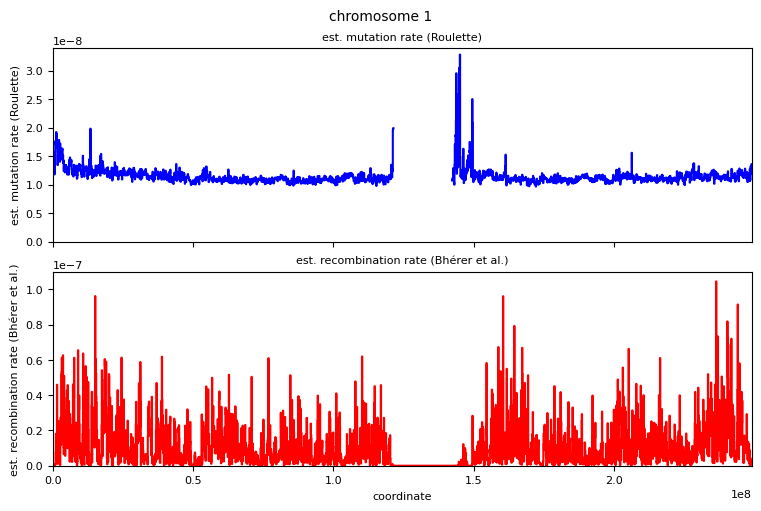

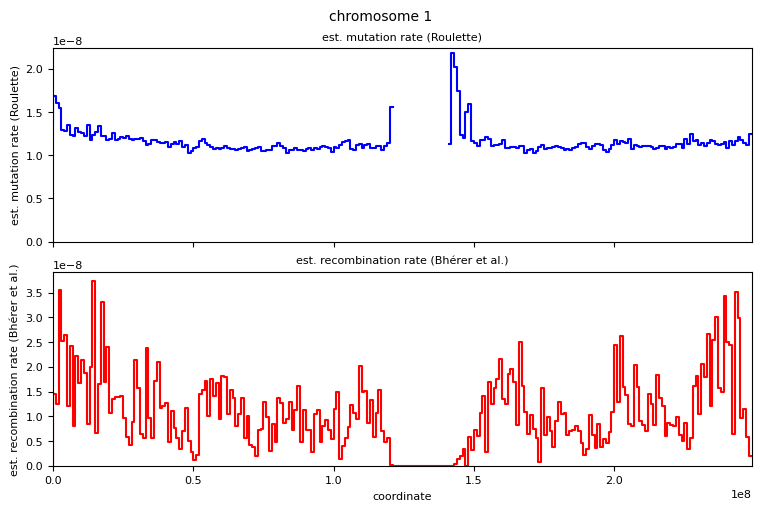

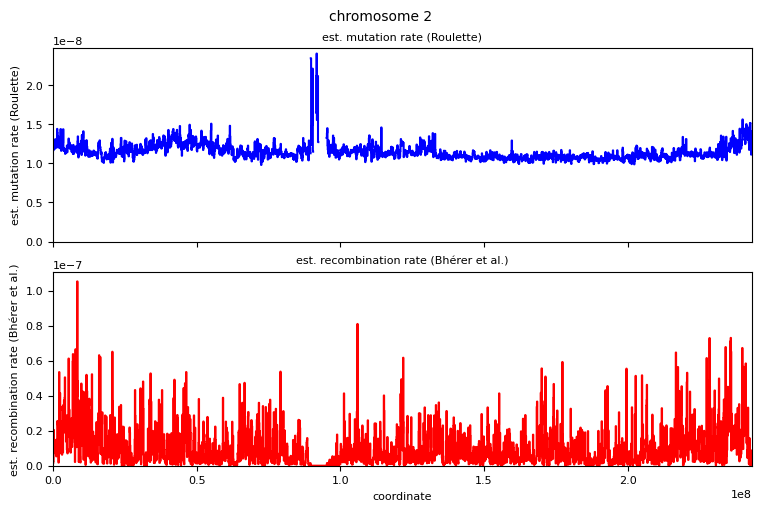

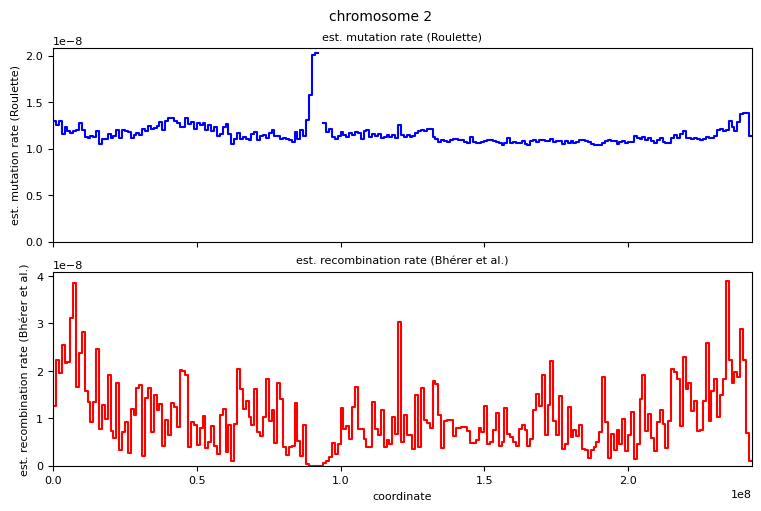

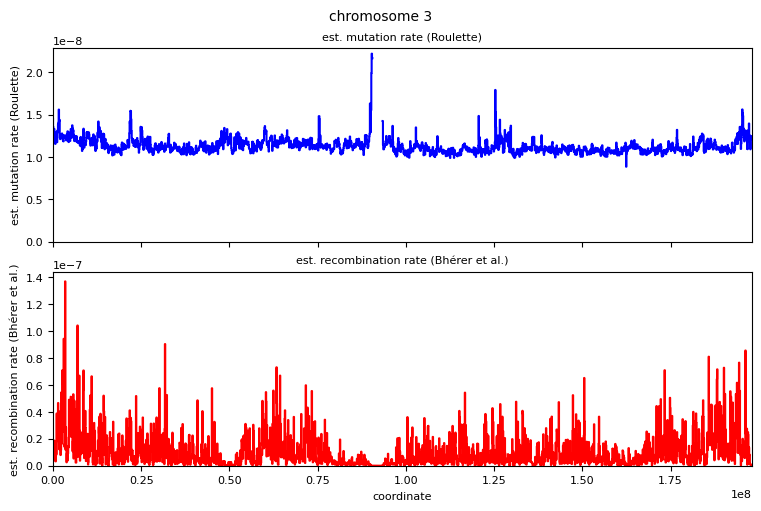

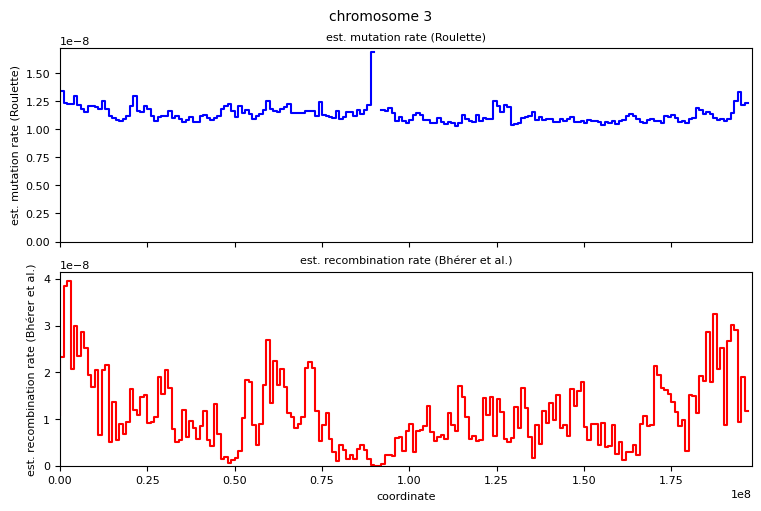

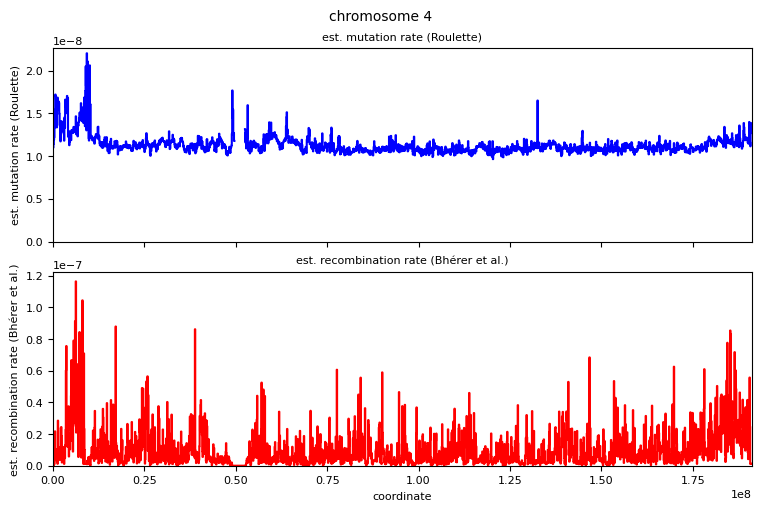

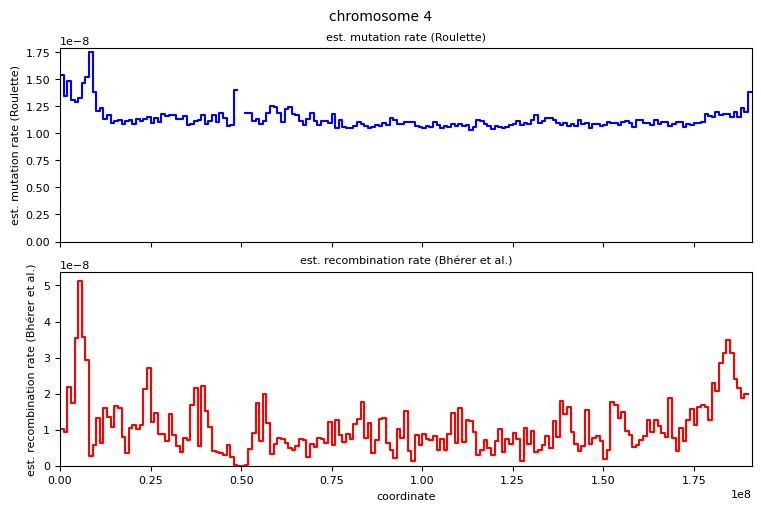

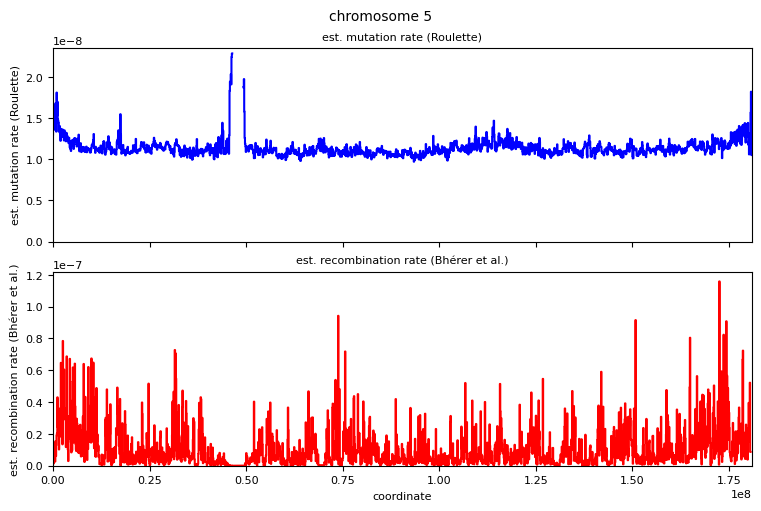

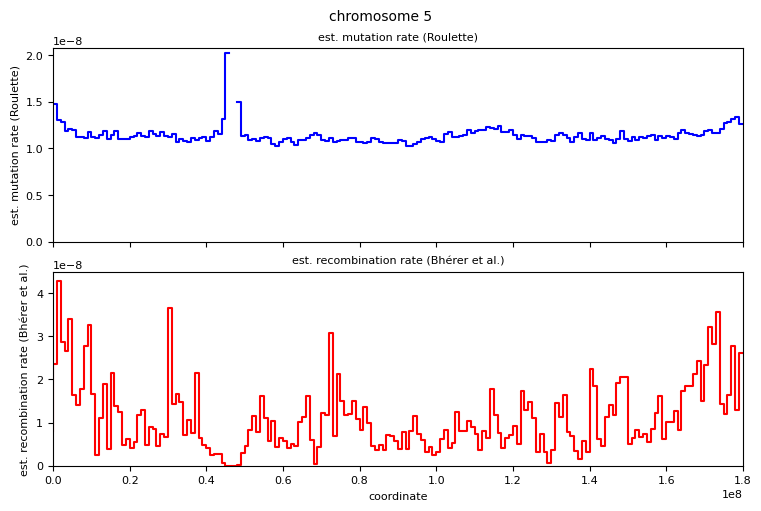

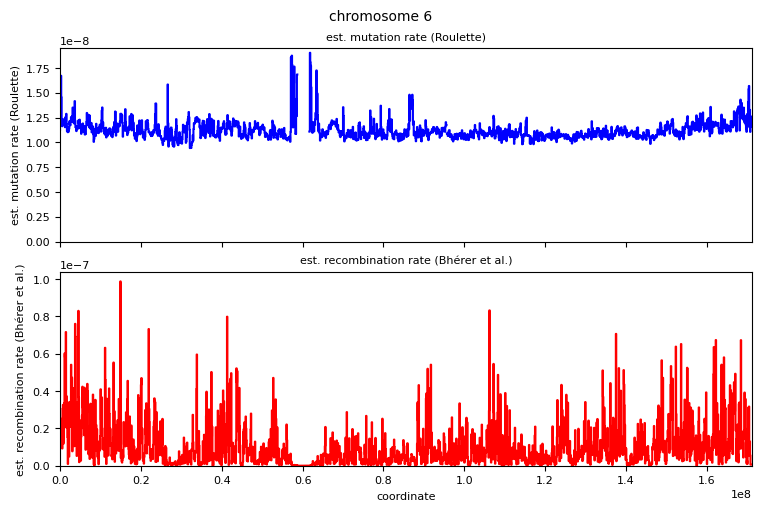

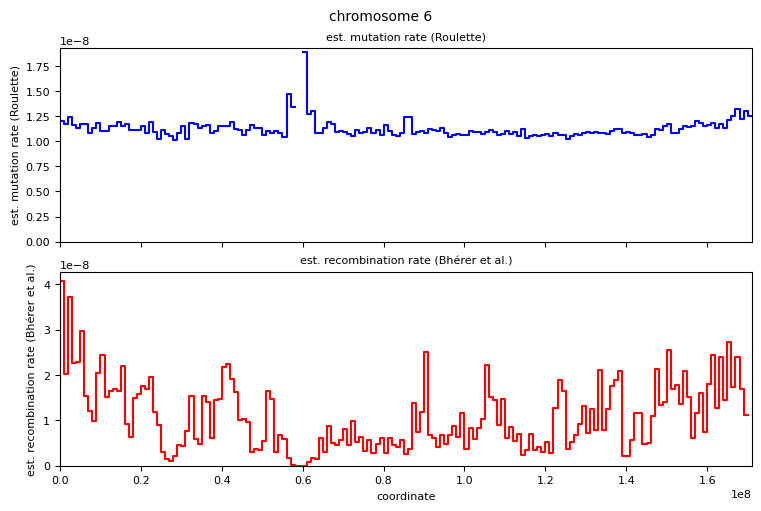

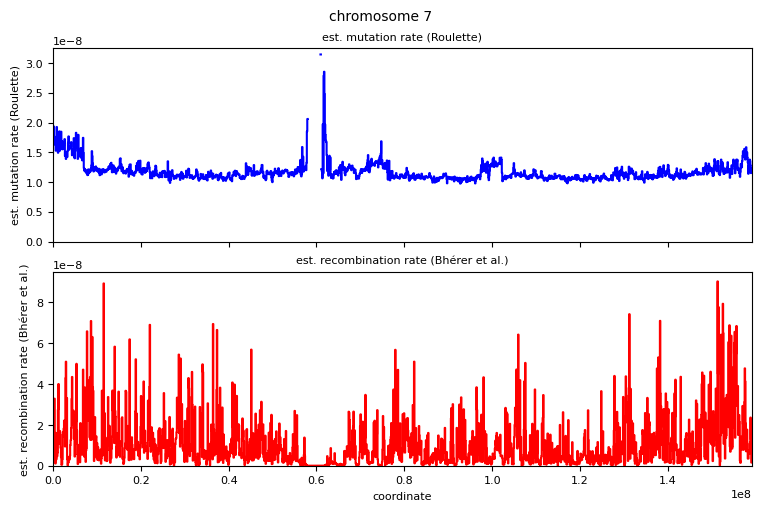

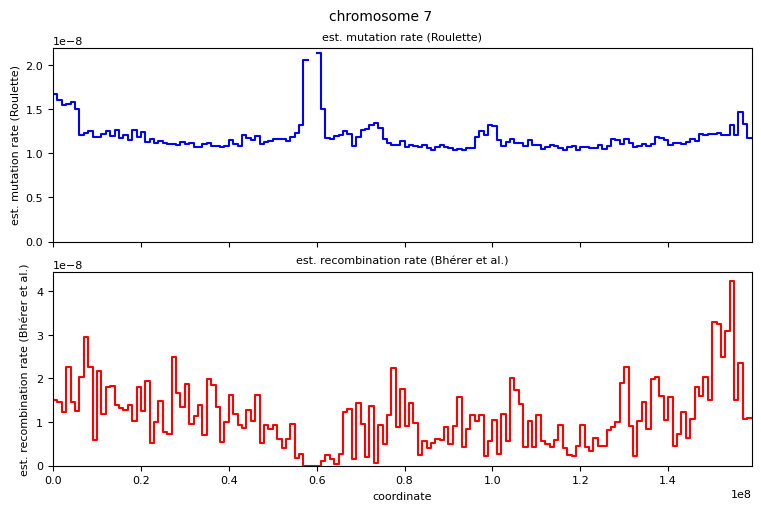

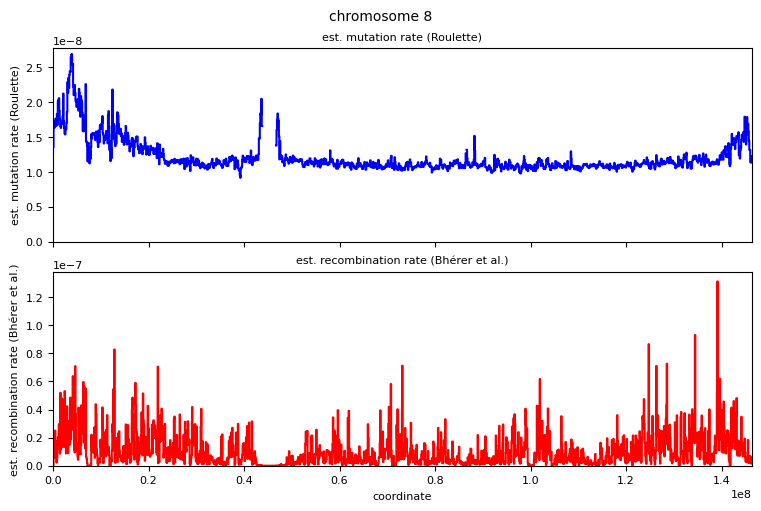

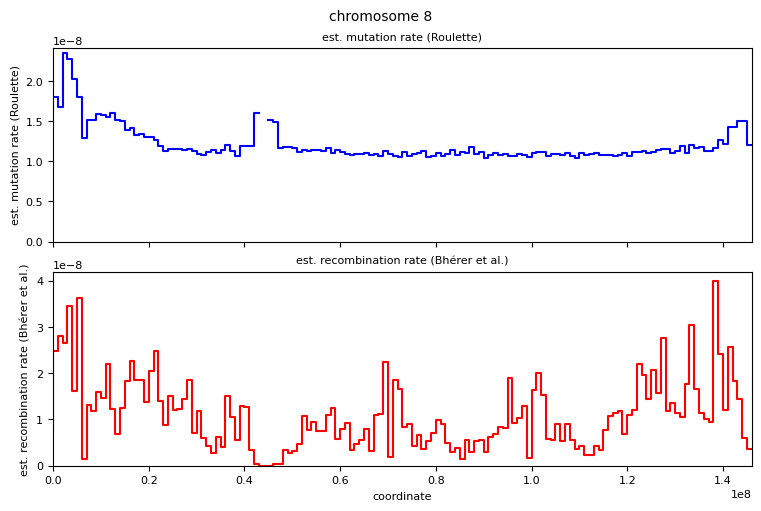

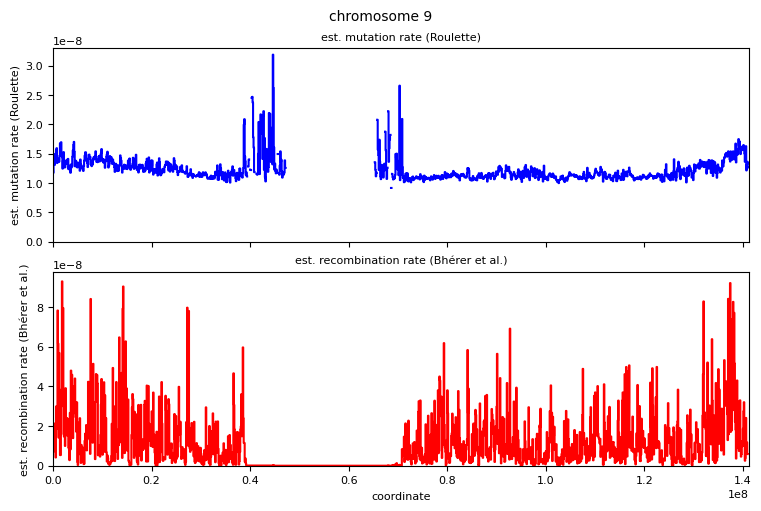

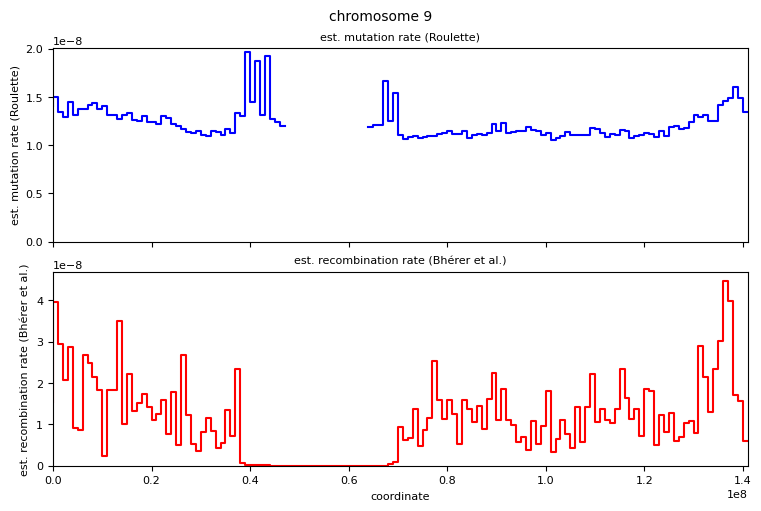

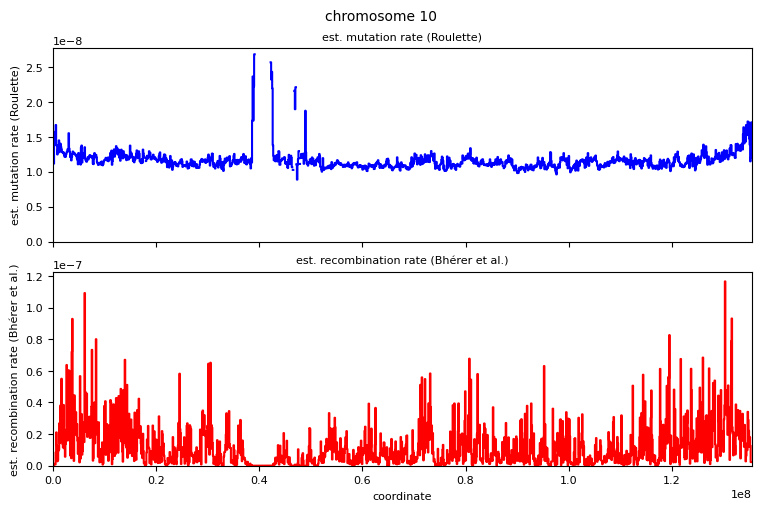

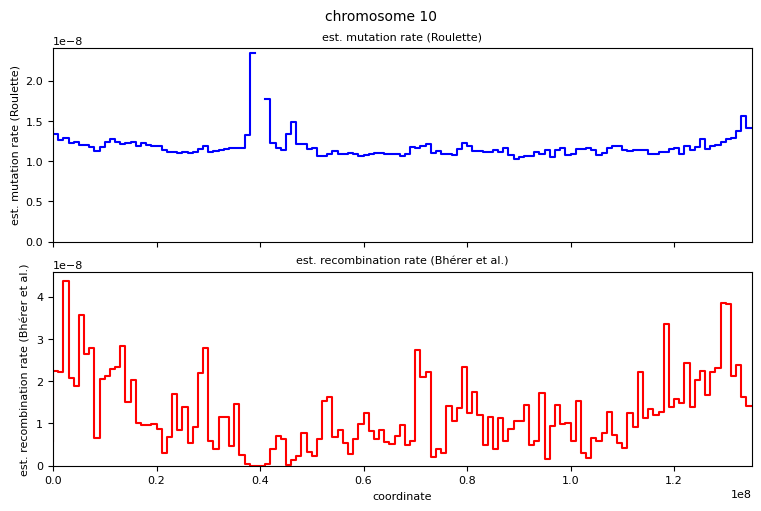

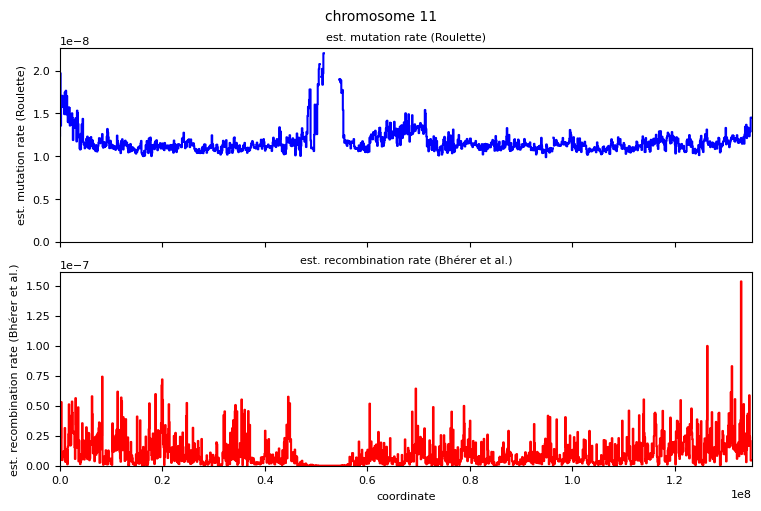

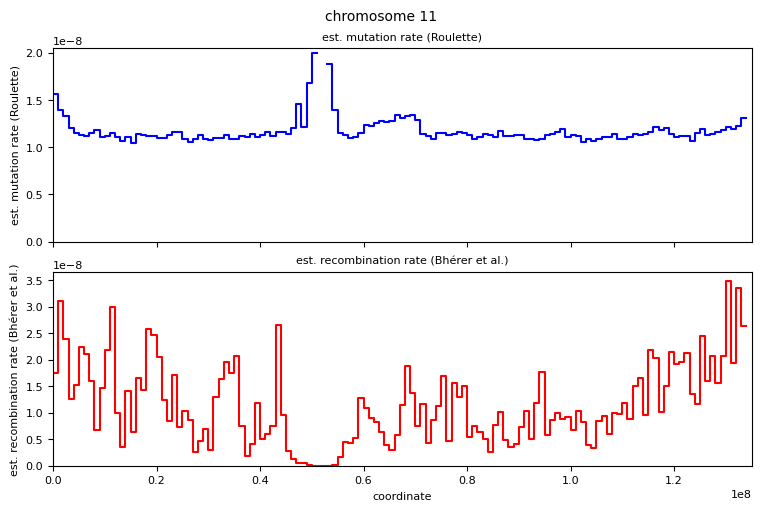

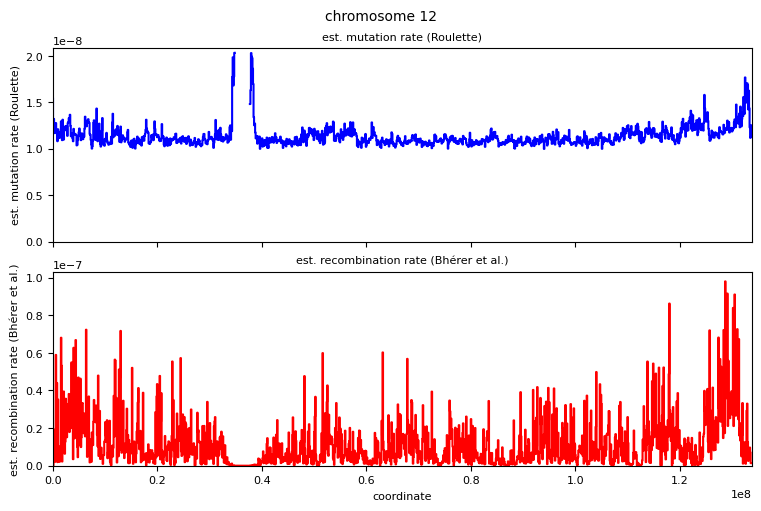

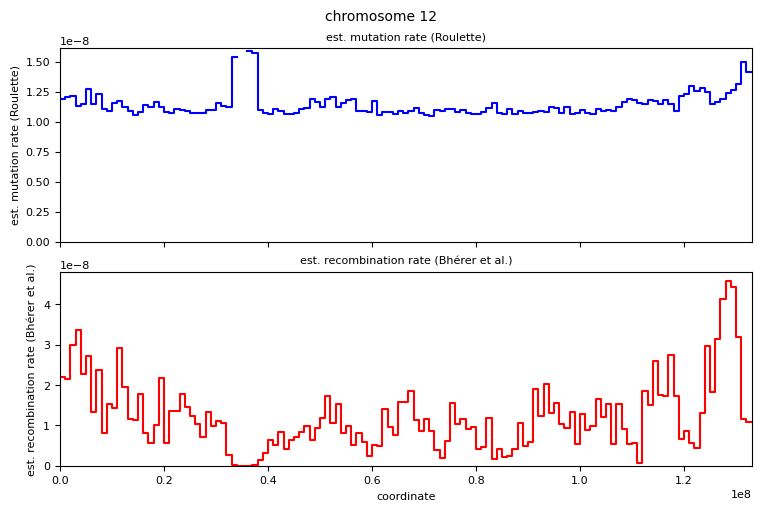

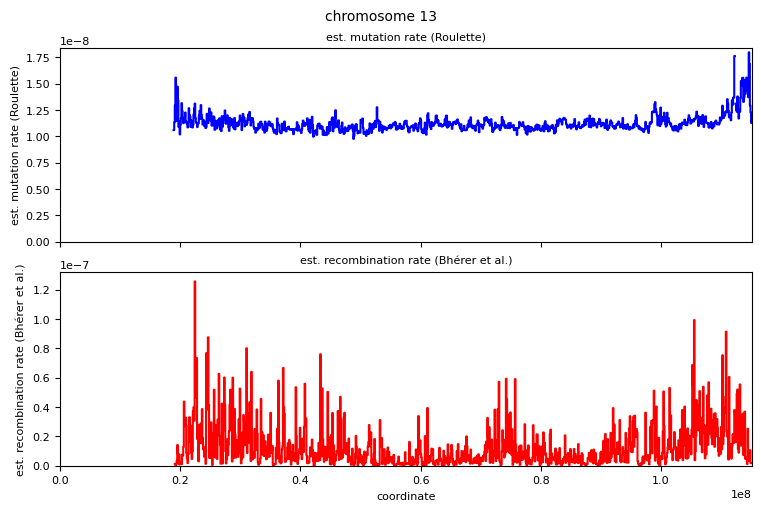

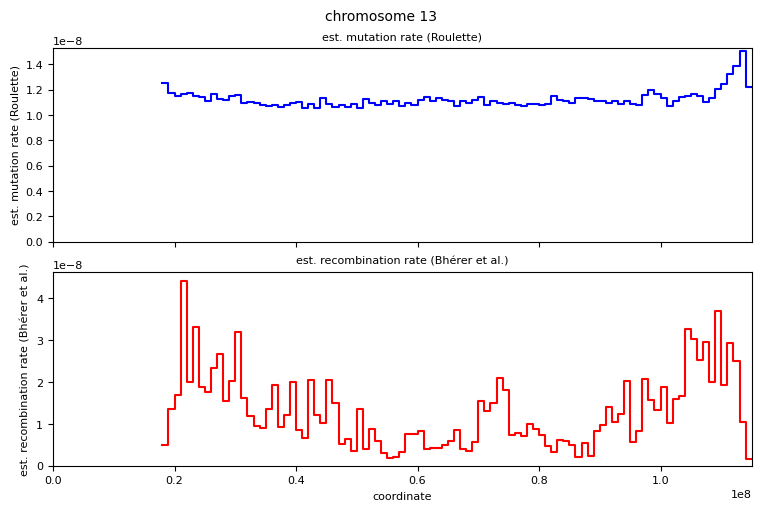

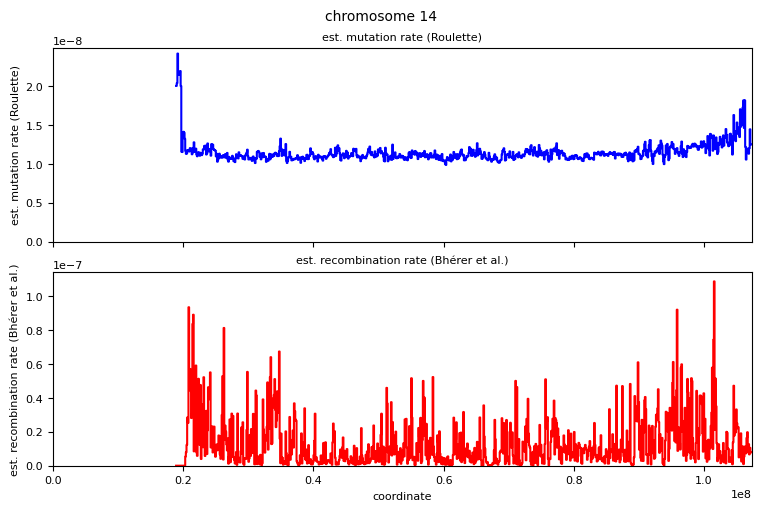

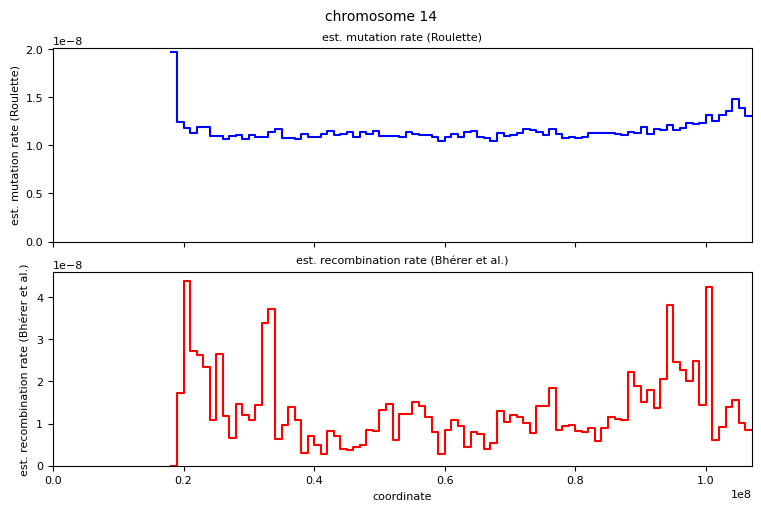

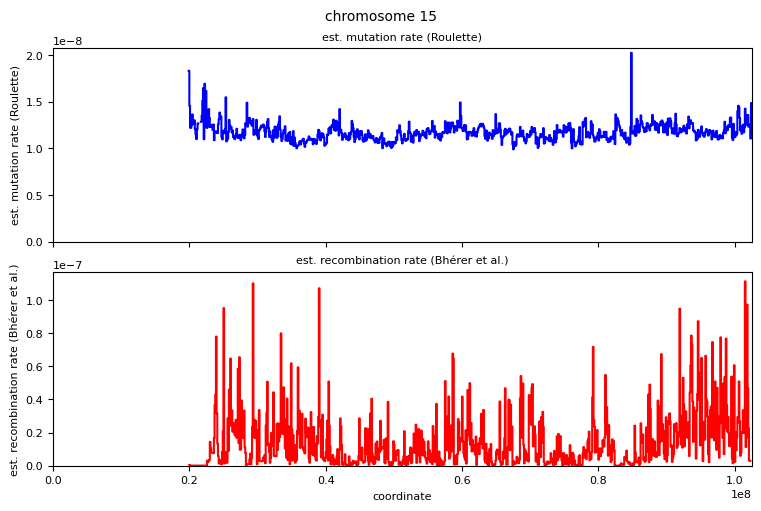

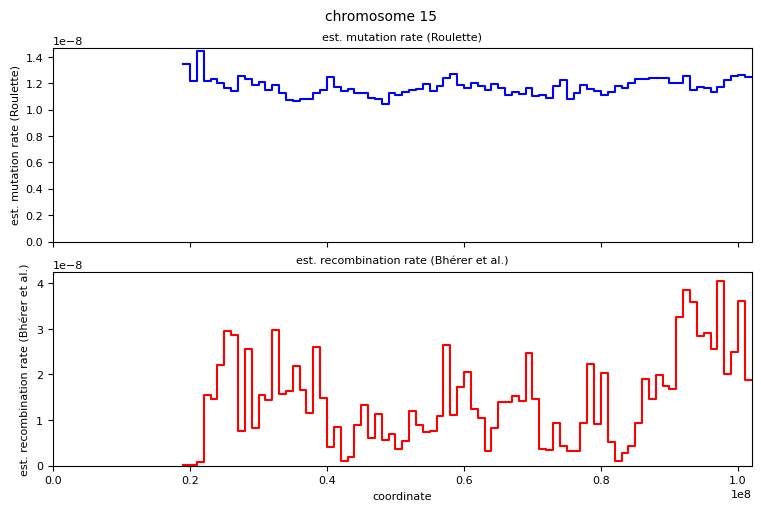

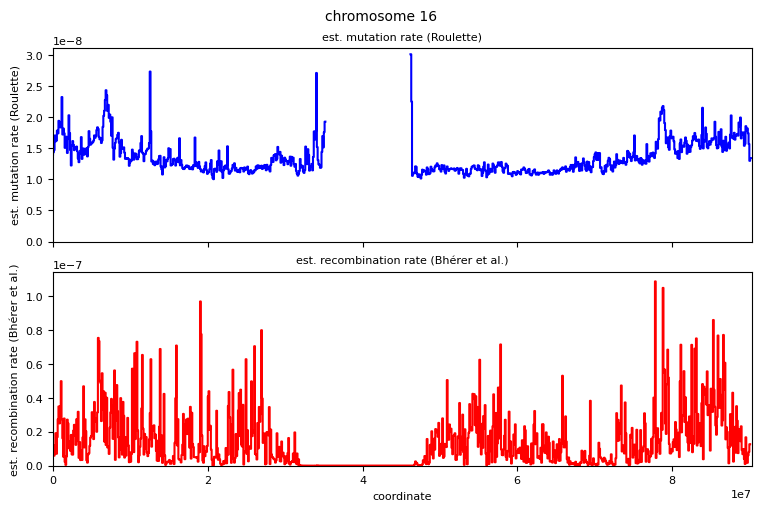

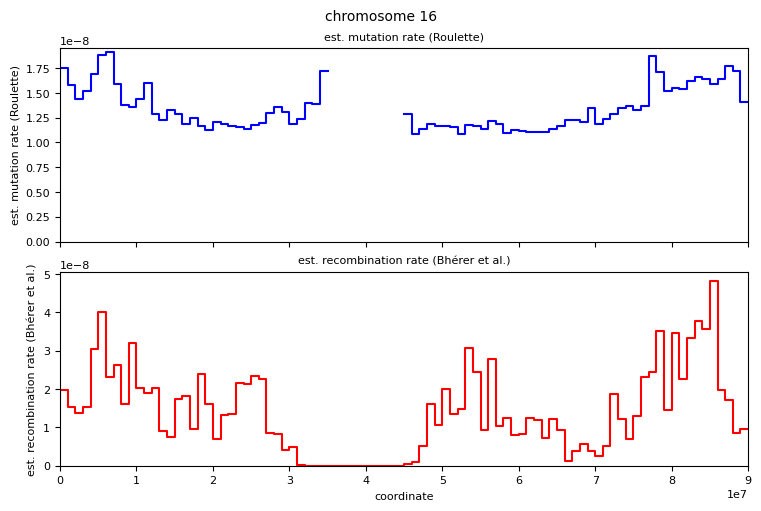

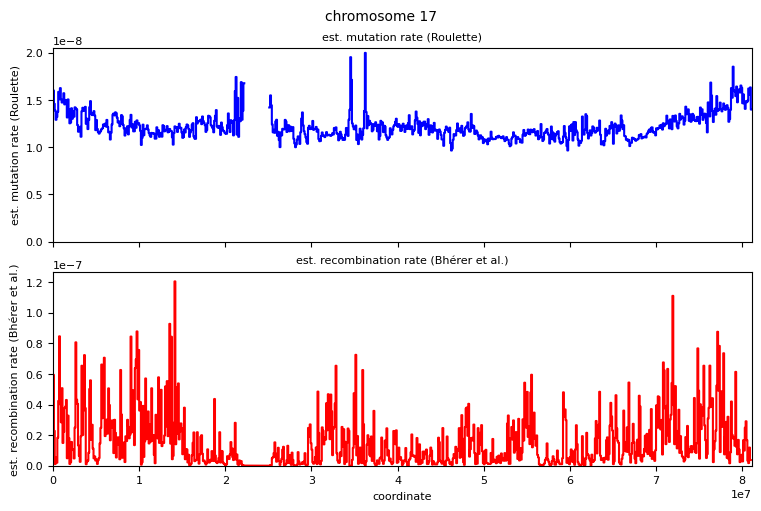

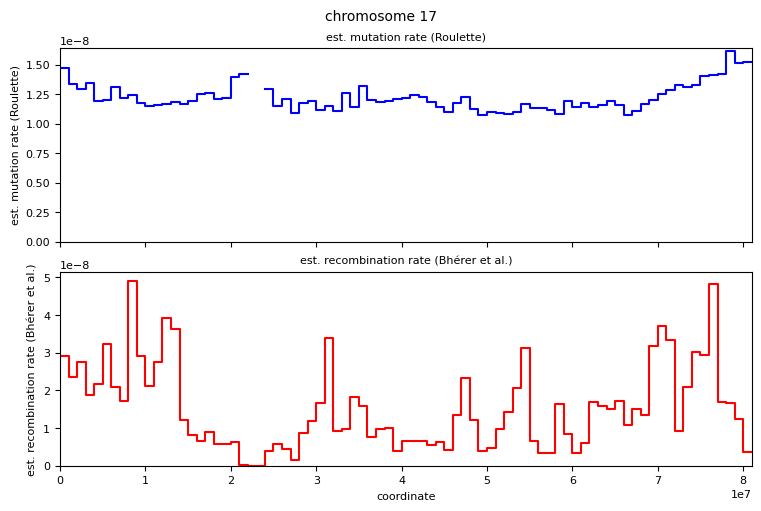

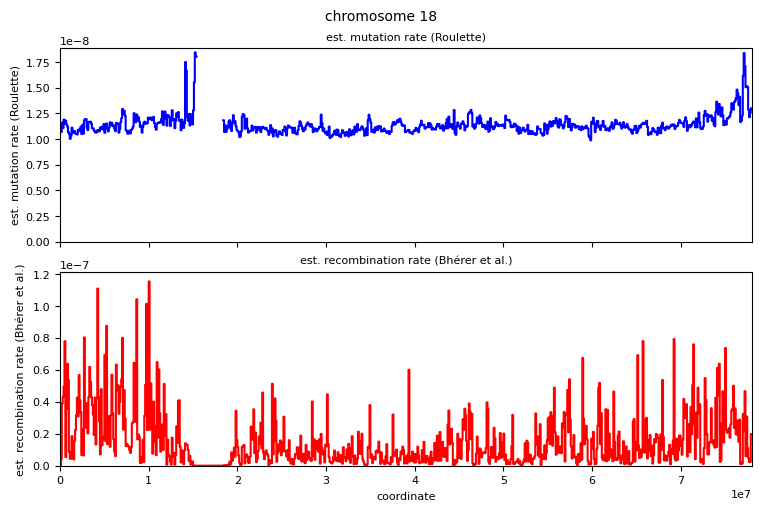

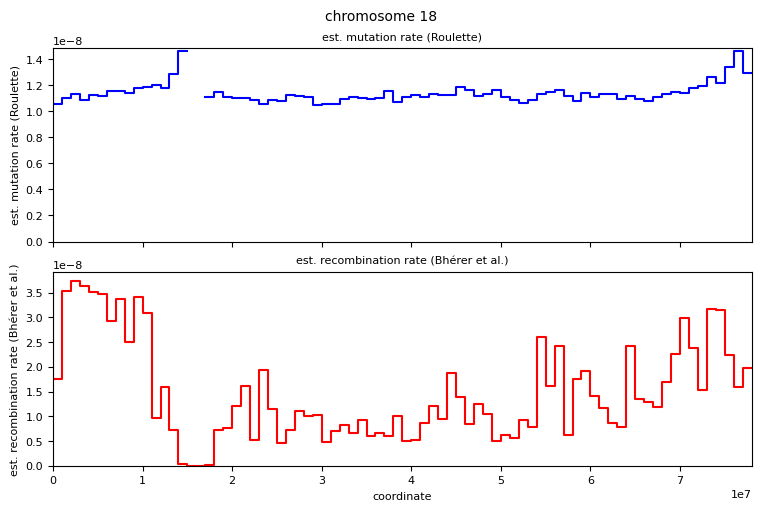

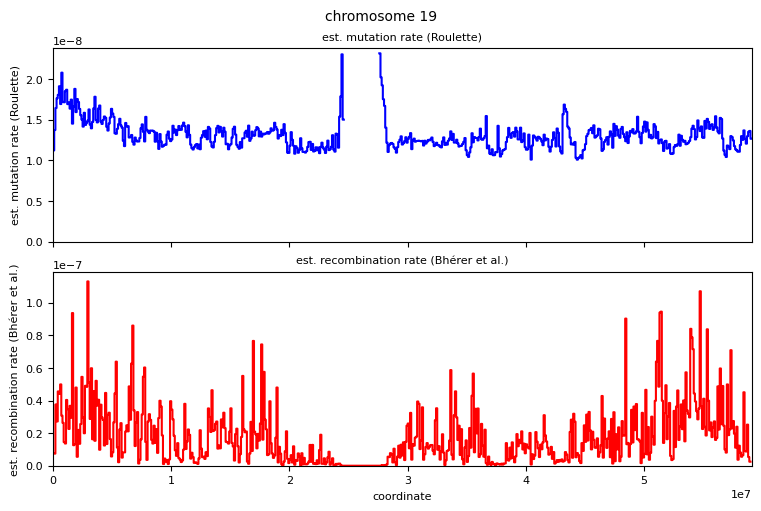

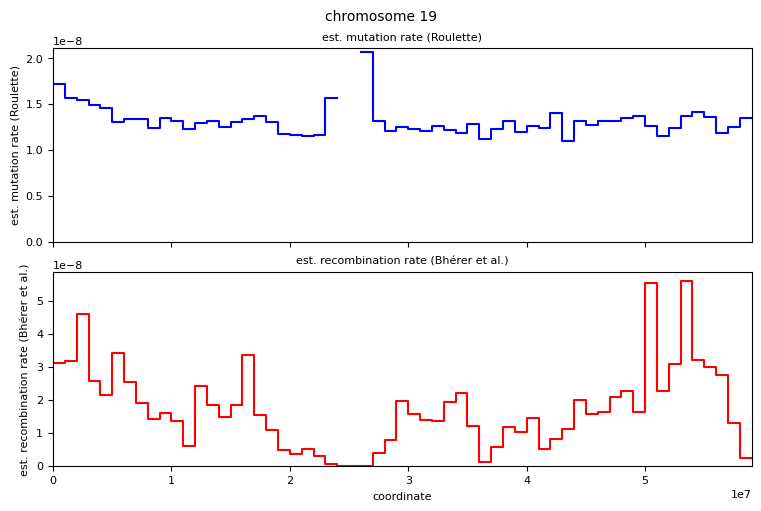

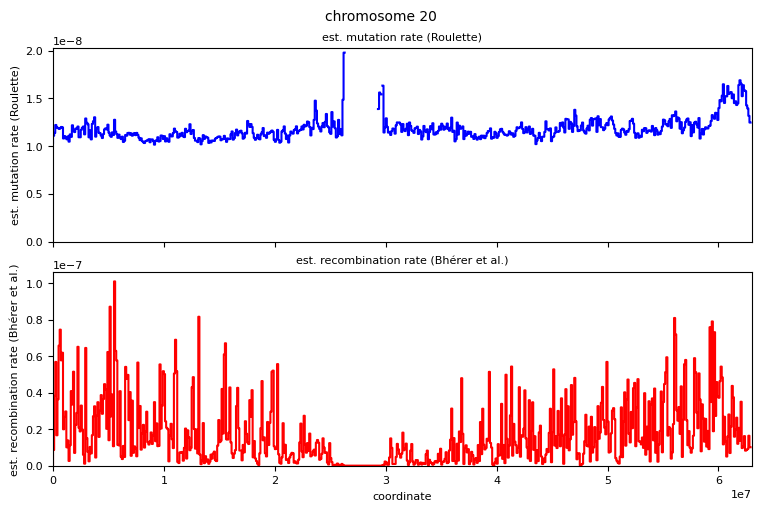

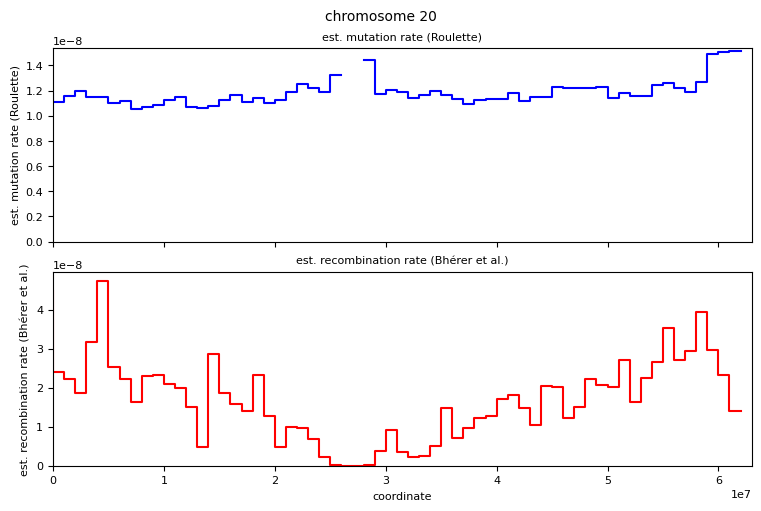

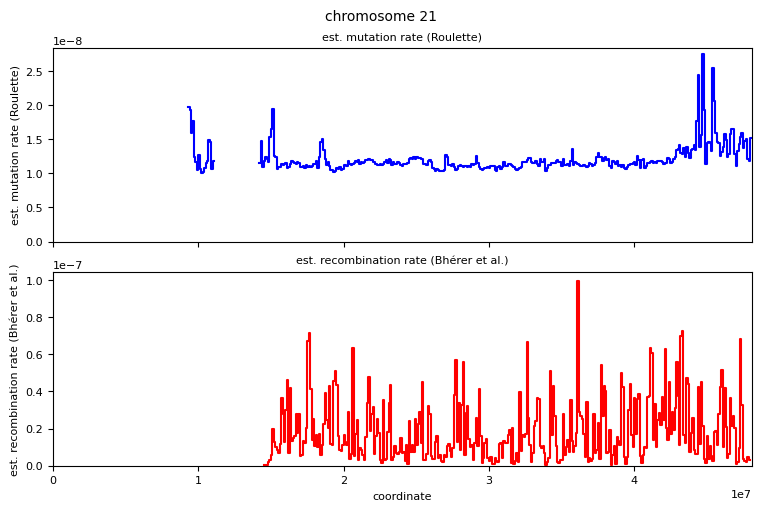

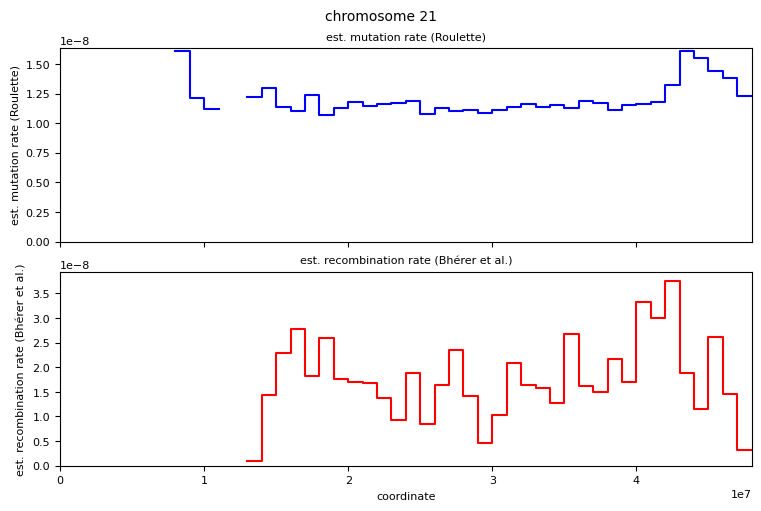

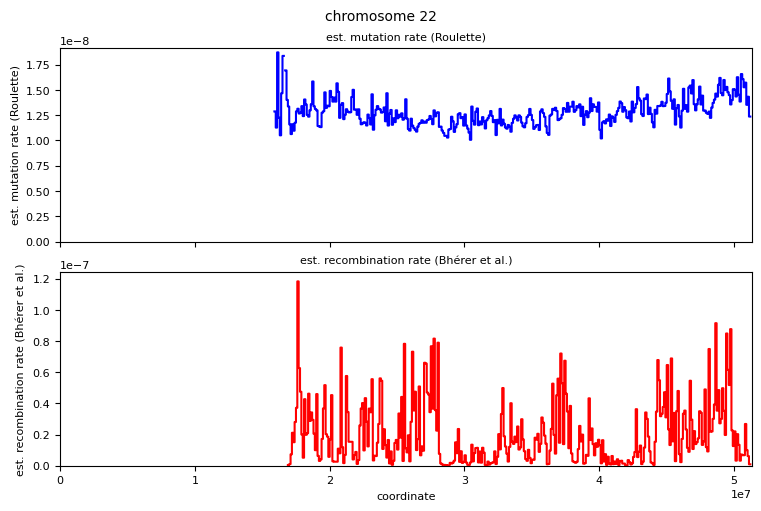

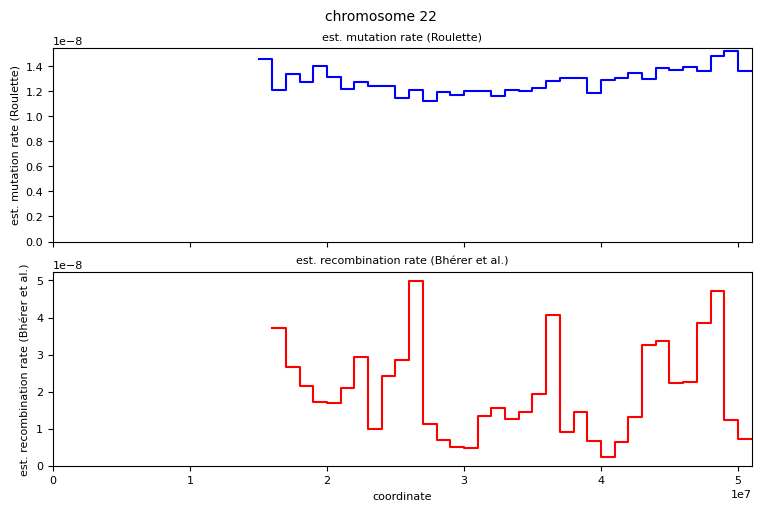

In [162]:
for chrom in range(1, 23):
    for scale in [int(1e5), int(1e6)]:
        # Load files and construct maps

        mut_file = f"../../data/mutation_maps/roulette_b37/roulette_b37_chr{chrom}.npy"
        site_mut_map = np.load(mut_file)
        windows = np.stack((np.arange(0, len(site_mut_map), scale),
                            np.arange(scale, len(site_mut_map) + scale, scale)), axis=1)
        mut_map = np.zeros(len(windows), np.float64)
        for i, (start, end) in enumerate(windows):
            mut_map[i] = np.nanmean(site_mut_map[start:end])


        rec_file = f"../../data/recombination_maps/Bherer_b37/sexavg_chr{chrom}.txt.gz"
        rec_tbl = pandas.read_csv(rec_file, sep="\t")
        positions = np.array(rec_tbl["pos"])
        positions = np.append(positions, positions[-1])
        rates = np.array(rec_tbl["rate"])
        site_rec_map = np.full(windows[-1, 1], np.nan)

        for i, (start, rate) in enumerate(zip(positions, rates)):
            end = positions[i + 1]
            site_rec_map[start:end] = rate

        rec_map = np.zeros(len(windows), np.float64)
        for i, (start, end) in enumerate(windows):
            rec_map[i] = np.nanmean(site_rec_map[start:end])
        rec_map *= 1e-8


        # Make figure
        fig, axs = plt.subplots(
            2, 1, figsize=(7.5, 5), sharex=True, layout="constrained")
        ax0, ax1 = axs
        fig.suptitle(f"chromosome {chrom}", size=10)
        ax0.step(windows[:, 0], mut_map, color="blue")
        ax0.set_xlim(0, windows[-1, 0])
        ax0.set_ylim(0, )
        ax0.set_ylabel("est. mutation rate (Roulette)")
        ax0.set_title("est. mutation rate (Roulette)")

        ax1.set_xlabel("coordinate")
        ax1.step(windows[:, 0], rec_map, color="red")
        ax1.set_ylim(0, )
        ax1.set_ylabel("est. recombination rate (Bhérer et al.)")
        ax1.set_title("est. recombination rate (Bhérer et al.)")

        plt.savefig(f"figures/map_figure_chr{chrom}_{int(scale/1e3)}kb.png", dpi=300)